In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [18]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
# Convert TotalCharges to numeric; blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many became NaN
print(df['TotalCharges'].isnull().sum())

# These are customers with 0 tenure — fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

11


In [20]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn rate: {churn_counts['Yes'] / len(df):.2%}")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


### Class Imbalance Note

The dataset shows a class imbalance — significantly more customers 
did not churn than did. This means accuracy alone could be misleading 
for this problem, and precision/recall should be checked per class 
when evaluating the models later.

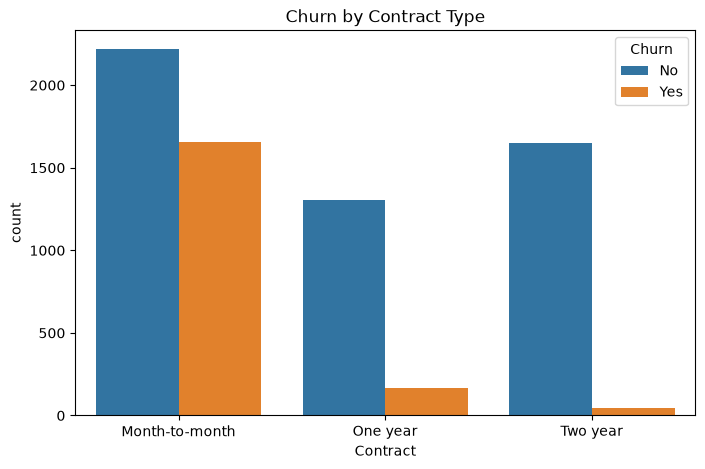

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

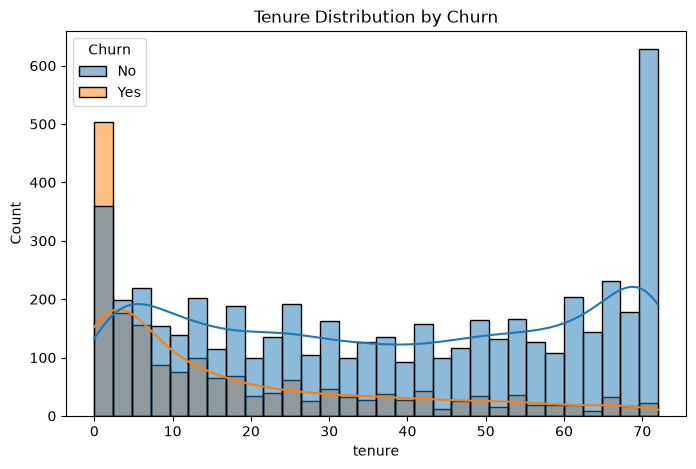

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.show()

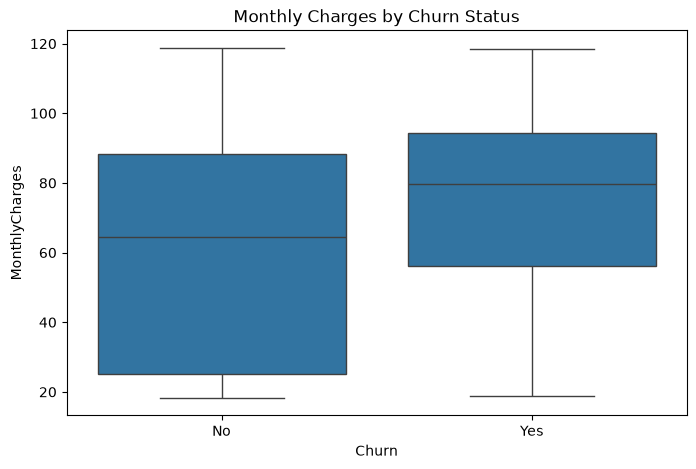

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')
plt.show()

In [24]:
# Drop customerID (not predictive) and separate target
df_model = df.drop(columns=['customerID'])

# Convert target to binary
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode remaining categorical columns
df_model = pd.get_dummies(df_model, drop_first=True)

df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [25]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 5634
Test set size: 1409


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test, log_pred)

print(f"Logistic Regression Accuracy: {log_accuracy:.2%}")
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 80.70%
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [28]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42, max_depth=6)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)

print(f"Decision Tree Accuracy: {tree_accuracy:.2%}")
print(classification_report(y_test, tree_pred))

Decision Tree Accuracy: 80.06%
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [29]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [f"{log_accuracy:.2%}", f"{tree_accuracy:.2%}"]
})
comparison

,Model,Accuracy
0,Logistic Regression,80.70%
1,Decision Tree,80.06%


In [30]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 3 features driving churn:")
importances.head(3)

Top 3 features driving churn:


,Feature,Importance
1,tenure,0.389640
10,InternetService_Fiber optic,0.327372
3,TotalCharges,0.051916


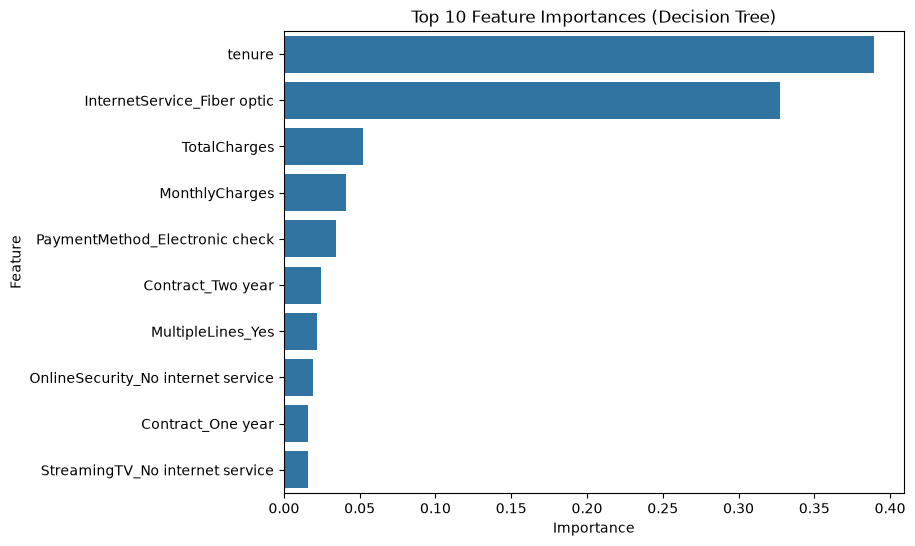

In [31]:
plt.figure(figsize=(8, 6))
top_features = importances.head(10)
sns.barplot(x='Importance', y='Feature', data=top_features)
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.show()

### Business Summary

Our analysis identified customer tenure and internet service type as 
the two strongest predictors of churn — customers who are newer to 
the company and those using fiber optic internet are significantly 
more likely to leave. Total charges also played a smaller role. Both 
models tested (Logistic Regression and Decision Tree) performed 
similarly, correctly predicting churn outcomes about 80% of the time. 
Given these findings, we recommend focusing retention efforts on new 
fiber optic customers in their first several months of service, as 
this segment shows the highest churn risk. Further investigation into 
why fiber optic customers churn more — such as pricing or service 
quality concerns — could help target the right retention offer.

### Model Comparison

Logistic Regression and Decision Tree performed almost identically 
on this dataset — 80.41% vs 80.06% accuracy. This suggests the 
relationship between these features and churn is largely linear or 
simple enough that a more complex model (Decision Tree) doesn't gain 
much advantage. The Decision Tree does offer an added benefit though: 
clear feature importance rankings, which directly reveal *why* 
customers churn — something Logistic Regression coefficients can 
approximate but less intuitively.